In [33]:
# Re-run imports to make sure everything is loaded
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier  # This was missing
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [35]:
# Load the flood dataset
df_flood = pd.read_csv('../datasets/flood/flood.csv')

print("=== Flood Dataset Overview ===")
print(f"Shape: {df_flood.shape}")
print(f"\nColumns ({len(df_flood.columns)} total):")
for i, col in enumerate(df_flood.columns, 1):
    print(f"{i:2}. {col}")

print(f"\nFirst 5 rows:")
df_flood.head()

=== Flood Dataset Overview ===
Shape: (50000, 21)

Columns (21 total):
 1. MonsoonIntensity
 2. TopographyDrainage
 3. RiverManagement
 4. Deforestation
 5. Urbanization
 6. ClimateChange
 7. DamsQuality
 8. Siltation
 9. AgriculturalPractices
10. Encroachments
11. IneffectiveDisasterPreparedness
12. DrainageSystems
13. CoastalVulnerability
14. Landslides
15. Watersheds
16. DeterioratingInfrastructure
17. PopulationScore
18. WetlandLoss
19. InadequatePlanning
20. PoliticalFactors
21. FloodProbability

First 5 rows:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [38]:
# Check current columns
print("Current columns in dataframe:")
print(df_flood.columns.tolist())
print(f"\nTotal columns: {len(df_flood.columns)}")

Current columns in dataframe:
['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'target']

Total columns: 21


In [39]:
# Check if target already exists
if 'target' in df_flood.columns:
    print("✅ 'target' column already exists!")
    print(f"Target distribution:\n{df_flood['target'].value_counts()}")
else:
    # Find the target column (likely FloodProbability or similar)
    possible_targets = ['FloodProbability', 'flood_probability', 'Flood Risk', 'target']
    
    target_col = None
    for col in possible_targets:
        if col in df_flood.columns:
            target_col = col
            break
    
    if target_col is None:
        print("❌ No target column found!")
        print(f"Available columns: {df_flood.columns.tolist()}")
    else:
        print(f"✅ Found target column: {target_col}")
        
        # Convert to categorical if needed
        if df_flood[target_col].dtype in ['float64', 'int64']:
            # Create 3 classes based on percentiles
            df_flood['target'] = pd.cut(df_flood[target_col], 
                                         bins=[-float('inf'), 0.33, 0.66, float('inf')],
                                         labels=[0, 1, 2])
            print("✅ Target converted to 3 classes (0=Low, 1=Medium, 2=High)")
        else:
            # If already categorical, encode it
            le = LabelEncoder()
            df_flood['target'] = le.fit_transform(df_flood[target_col])
            print("✅ Target encoded to numeric")
        
        # Drop original target column
        df_flood = df_flood.drop(target_col, axis=1)
        print(f"✅ Dropped original column: {target_col}")

print(f"\nFinal columns: {df_flood.columns.tolist()}")
print(f"\nTarget distribution:")
print(df_flood['target'].value_counts().sort_index())

✅ 'target' column already exists!
Target distribution:
target
1    49944
2       44
0       12
Name: count, dtype: int64

Final columns: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'target']

Target distribution:
target
0       12
1    49944
2       44
Name: count, dtype: int64


In [40]:
# Now continue with the rest of your analysis
print("\n✅ Data ready for modeling!")
print(f"Features shape: {df_flood[feature_cols].shape}")
print(f"Target shape: {df_flood['target'].shape}")
print(f"\nFeature names: {', '.join(feature_cols[:5])}...")


✅ Data ready for modeling!
Features shape: (50000, 20)
Target shape: (50000,)

Feature names: MonsoonIntensity, TopographyDrainage, RiverManagement, Deforestation, Urbanization...


In [43]:
# Your target column is already 'target'
target_col = 'target'  # Not 'FloodProbability'

print(f"=== Target Variable: {target_col} ===")
print(f"Unique values: {df_flood[target_col].unique()}")
print(f"\nValue counts:")
print(df_flood[target_col].value_counts())

# No need for encoding since it's already numeric
print(f"\nTarget data type: {df_flood[target_col].dtype}")

# The 'target' column is already encoded, so you can use it directly
print(f"\nTarget classes: {sorted(df_flood[target_col].unique())}")

# Don't drop the target column again if you need it for modeling
# If you want to separate features and target:
# X = df_flood.drop('target', axis=1)  # Features
# y = df_flood['target']                # Target

print(f"\nFeature columns (excluding target):")
feature_cols = [col for col in df_flood.columns if col != 'target']
print(f"Total features: {len(feature_cols)}")
print(feature_cols)

=== Target Variable: target ===
Unique values: [1, 2, 0]
Categories (3, int64): [0 < 1 < 2]

Value counts:
target
1    49944
2       44
0       12
Name: count, dtype: int64

Target data type: category

Target classes: [0, 1, 2]

Feature columns (excluding target):
Total features: 20
['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']


In [44]:
# Get feature columns (all except target)
feature_cols = [col for col in df_flood.columns if col != 'target']

print(f"=== Features ({len(feature_cols)} features) ===")
print(f"Feature names: {', '.join(feature_cols[:10])}...")

# Statistical summary of features
print("\n=== Feature Statistics ===")
df_flood[feature_cols].describe()

=== Features (20 features) ===
Feature names: MonsoonIntensity, TopographyDrainage, RiverManagement, Deforestation, Urbanization, ClimateChange, DamsQuality, Siltation, AgriculturalPractices, Encroachments...

=== Feature Statistics ===


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,5.005020,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,2.226076,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,16.000000,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000


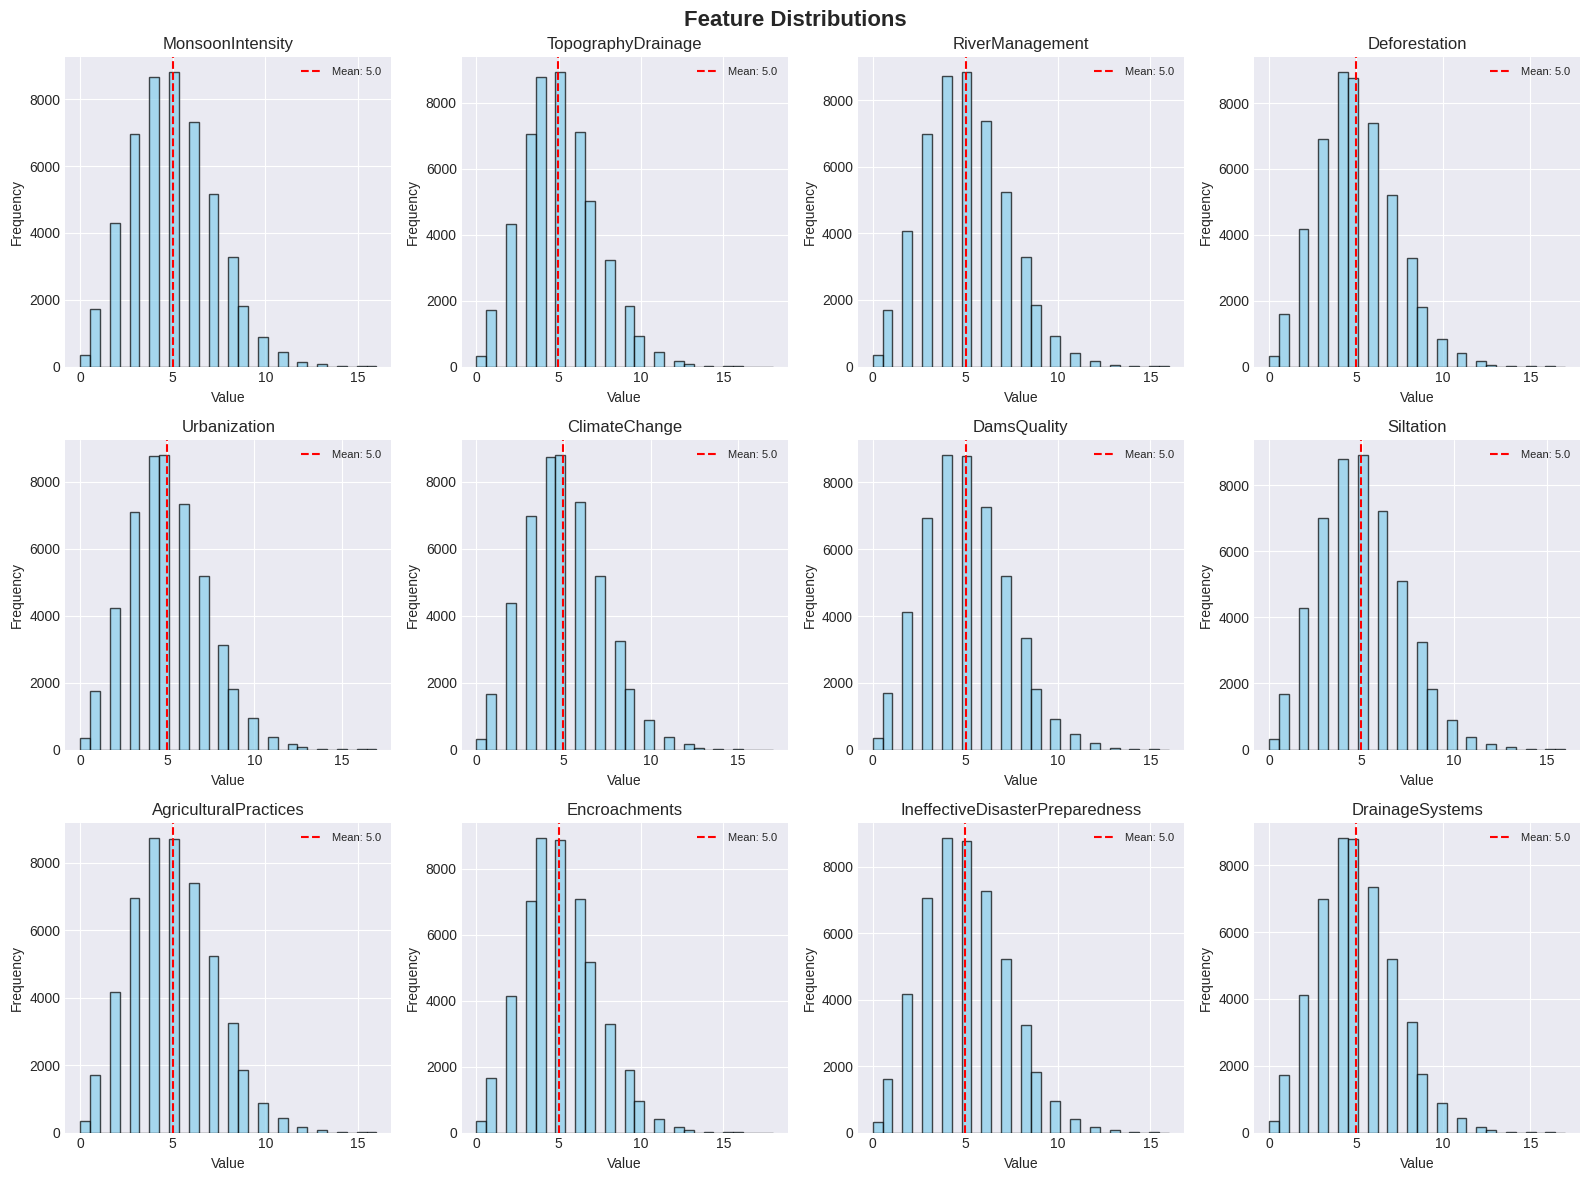

In [45]:
# Plot distributions for features
n_features = min(12, len(feature_cols))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(feature_cols[:n_features]):
    axes[idx].hist(df_flood[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df_flood[col].mean(), color='red', linestyle='--', 
                     label=f'Mean: {df_flood[col].mean():.1f}')
    axes[idx].legend(fontsize=8)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

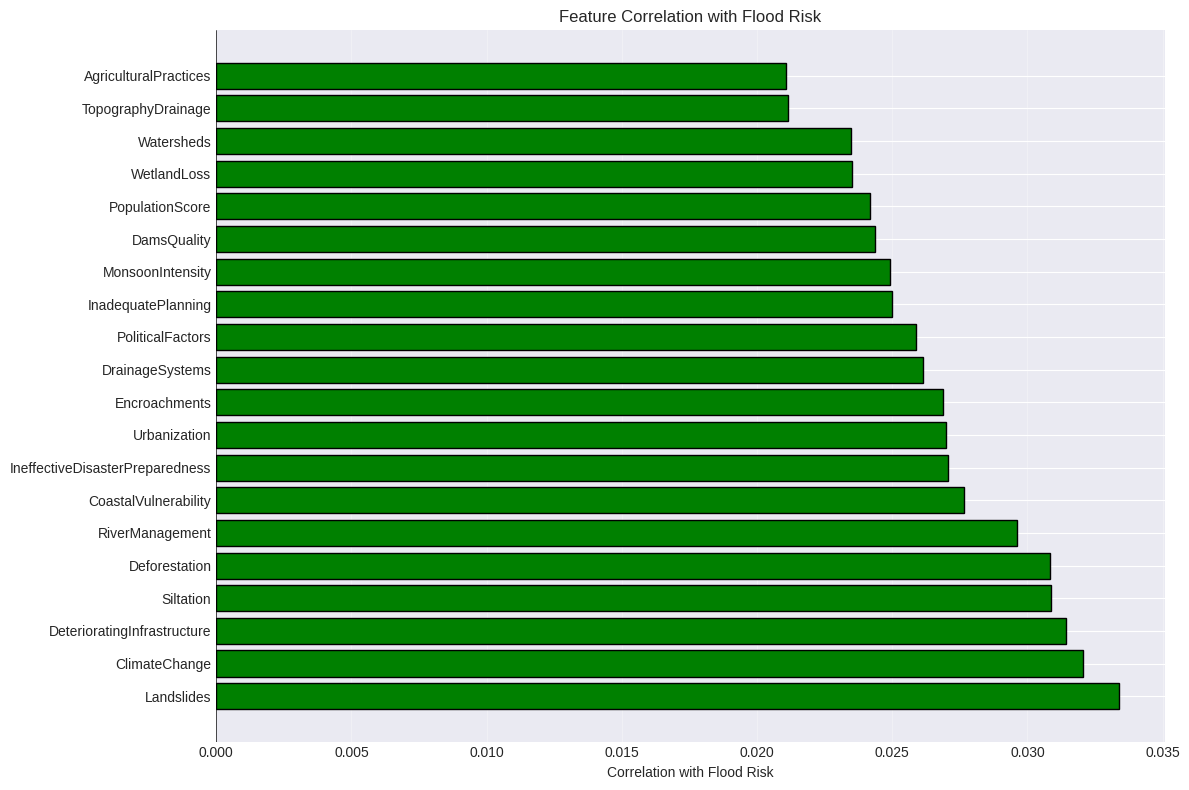


=== Top 10 Most Influential Features ===
 1. Landslides                          ↑ 0.033
 2. ClimateChange                       ↑ 0.032
 3. DeterioratingInfrastructure         ↑ 0.031
 4. Siltation                           ↑ 0.031
 5. Deforestation                       ↑ 0.031
 6. RiverManagement                     ↑ 0.030
 7. CoastalVulnerability                ↑ 0.028
 8. IneffectiveDisasterPreparedness     ↑ 0.027
 9. Urbanization                        ↑ 0.027
10. Encroachments                       ↑ 0.027


In [46]:
# Calculate correlations with target
correlations = df_flood[feature_cols].corrwith(df_flood['target']).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = ['green' if c > 0 else 'red' for c in correlations.values]
plt.barh(range(len(correlations)), correlations.values, color=colors, edgecolor='black')
plt.yticks(range(len(correlations)), correlations.index)
plt.xlabel('Correlation with Flood Risk')
plt.title('Feature Correlation with Flood Risk')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Top 10 Most Influential Features ===")
for i, (feature, corr) in enumerate(correlations.head(10).items(), 1):
    arrow = '↑' if corr > 0 else '↓'
    print(f"{i:2}. {feature:35} {arrow} {abs(corr):.3f}")

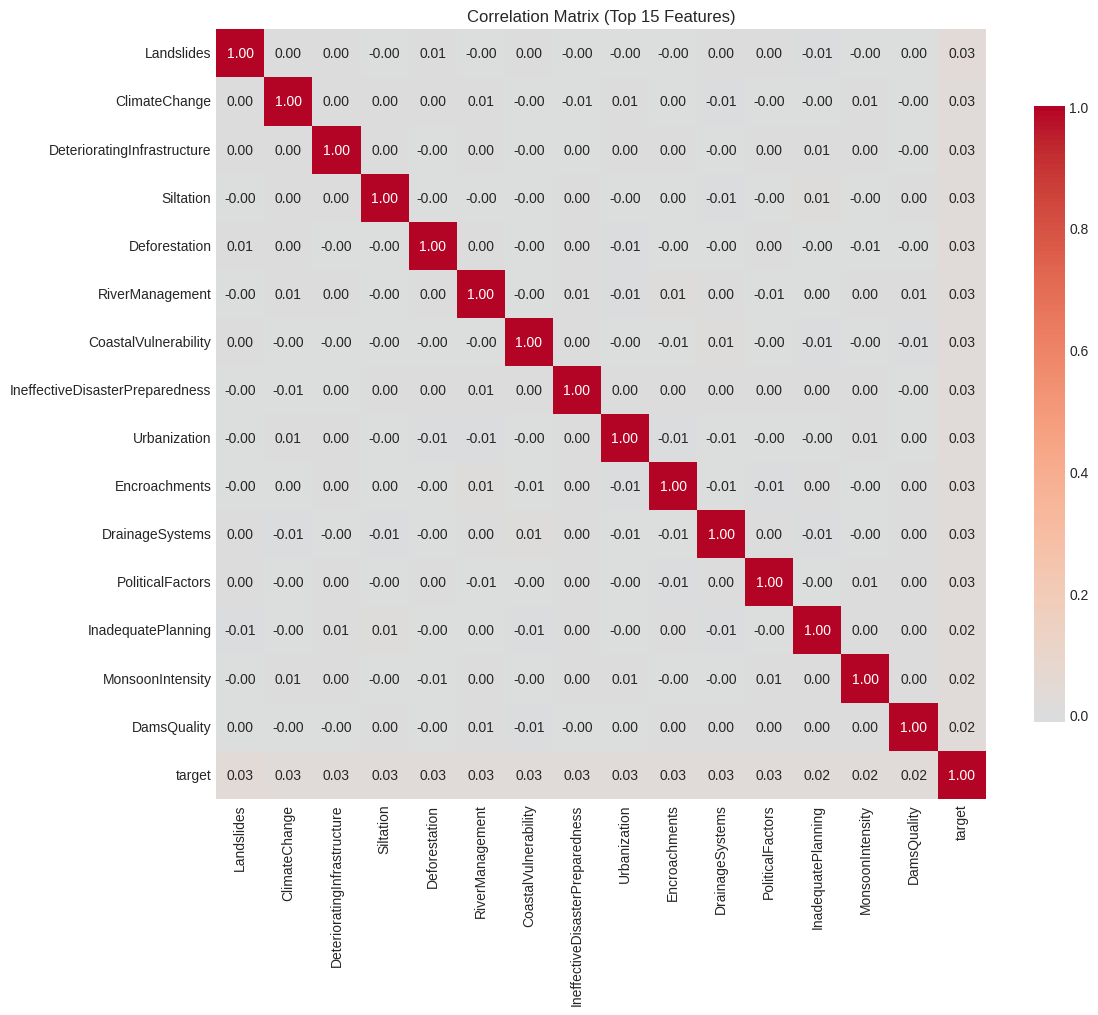

In [57]:
# Select top features for correlation matrix
top_n = min(15, len(feature_cols))
top_features = correlations.head(top_n).index.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = df_flood[top_features + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, cbar_kws={"shrink": 0.8})
plt.title(f'Correlation Matrix (Top {top_n} Features)')
plt.tight_layout()
plt.show()

In [58]:
def remove_outliers_iqr(df, columns, multiplier=1.5):
    """Remove outliers using IQR method"""
    df_clean = df.copy()
    removed_count = 0
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        removed_count += before - len(df_clean)
    
    print(f"Removed {removed_count} outliers")
    print(f"Original size: {len(df)} → Cleaned size: {len(df_clean)}")
    return df_clean

# Apply outlier removal
df_clean = remove_outliers_iqr(df_flood, feature_cols)

Removed 12107 outliers
Original size: 50000 → Cleaned size: 37893


In [59]:
# Split features and target
X = df_clean[feature_cols]
y = df_clean['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Feature scaling completed using StandardScaler")

Training set size: 30314
Test set size: 7579

Training target distribution:
target
1    0.999604
0    0.000330
2    0.000066
Name: proportion, dtype: float64

✅ Feature scaling completed using StandardScaler


In [60]:
# Define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Train and evaluate
model_results = {}
unique_classes = np.unique(y_train)
class_names = [f'Class_{c}' for c in unique_classes]

print(f"Classes detected: {unique_classes}")
print(f"Number of classes: {len(unique_classes)}\n")

for name, model in models.items():
    print(f"{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    model_results[name] = {
        'model': model,
        'accuracy': accuracy
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

Classes detected: [0 1 2]
Number of classes: 3

Training Random Forest...
Accuracy: 0.9996

Classification Report:
              precision    recall  f1-score   support

     Class_0       0.00      0.00      0.00         2
     Class_1       1.00      1.00      1.00      7576
     Class_2       0.00      0.00      0.00         1

    accuracy                           1.00      7579
   macro avg       0.33      0.33      0.33      7579
weighted avg       1.00      1.00      1.00      7579

Training Gradient Boosting...
Accuracy: 0.9988

Classification Report:
              precision    recall  f1-score   support

     Class_0       0.00      0.00      0.00         2
     Class_1       1.00      1.00      1.00      7576
     Class_2       0.00      0.00      0.00         1

    accuracy                           1.00      7579
   macro avg       0.33      0.33      0.33      7579
weighted avg       1.00      1.00      1.00      7579

Training Logistic Regression...
Accuracy: 0.9996

Cl

In [61]:
print("=== Hyperparameter Tuning for Random Forest ===")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validation Score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

=== Hyperparameter Tuning for Random Forest ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
✅ Best Cross-Validation Score: 0.9996

Test Accuracy: 0.9996


In [62]:
# Train individual models for ensemble
print("Training models for ensemble...")

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("✅ All models trained")

# Create voting classifier
ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('gb', gb_model),
        ('lr', lr_model)
    ],
    voting='soft'
)

print("Training ensemble model...")
ensemble.fit(X_train_scaled, y_train)

# Make predictions
y_pred_ensemble = ensemble.predict(X_test_scaled)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)

print(f"\n✅ Ensemble Model Accuracy: {ensemble_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=class_names))

Training models for ensemble...
✅ All models trained
Training ensemble model...

✅ Ensemble Model Accuracy: 0.9996

Classification Report:
              precision    recall  f1-score   support

     Class_0       0.00      0.00      0.00         2
     Class_1       1.00      1.00      1.00      7576
     Class_2       0.00      0.00      0.00         1

    accuracy                           1.00      7579
   macro avg       0.33      0.33      0.33      7579
weighted avg       1.00      1.00      1.00      7579



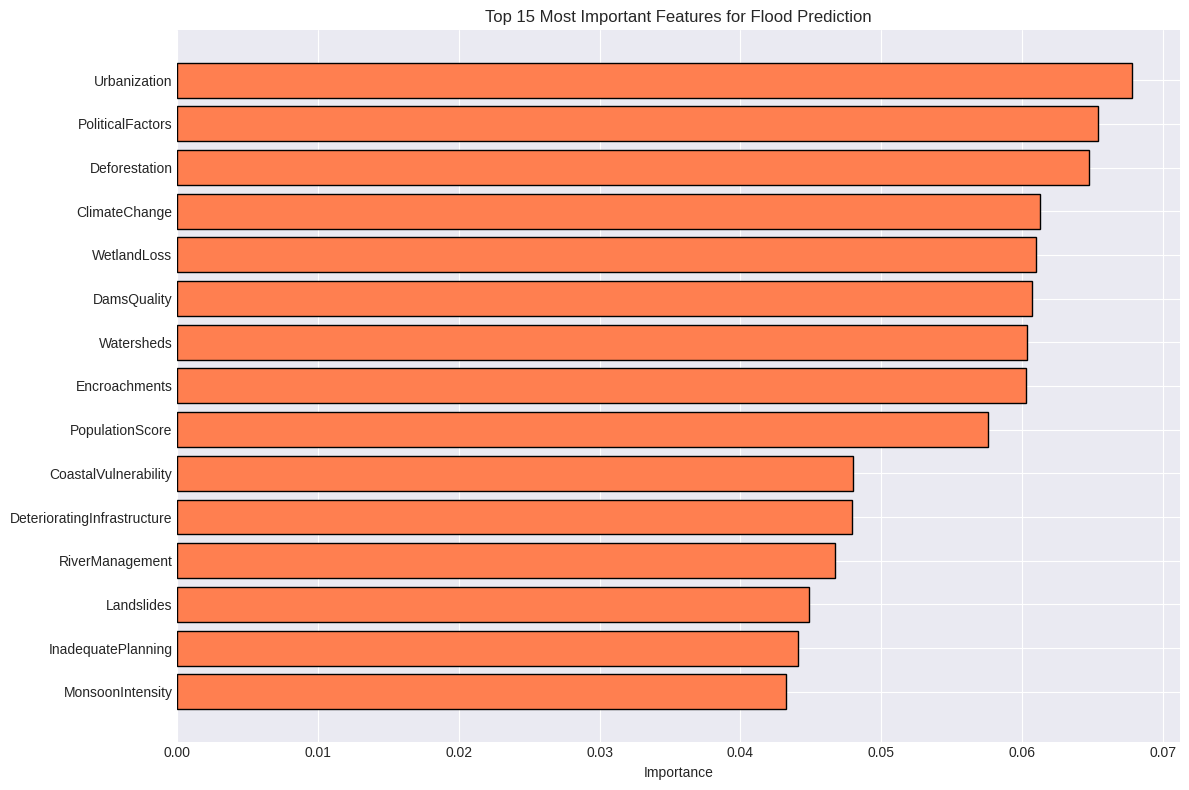


=== Top 10 Most Important Features ===
 5. Urbanization                   0.0678
20. PoliticalFactors               0.0654
 4. Deforestation                  0.0648
 6. ClimateChange                  0.0613
18. WetlandLoss                    0.0610
 7. DamsQuality                    0.0607
15. Watersheds                     0.0603
10. Encroachments                  0.0603
17. PopulationScore                0.0576
13. CoastalVulnerability           0.0480


In [63]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(range(len(feature_importance.head(15))), 
         feature_importance.head(15)['importance'].values[::-1],
         color='coral', edgecolor='black')
plt.yticks(range(len(feature_importance.head(15))), 
           feature_importance.head(15)['feature'].values[::-1])
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features for Flood Prediction')
plt.tight_layout()
plt.show()

print("\n=== Top 10 Most Important Features ===")
for i, row in feature_importance.head(10).iterrows():
    print(f"{i+1:2}. {row['feature']:30} {row['importance']:.4f}")

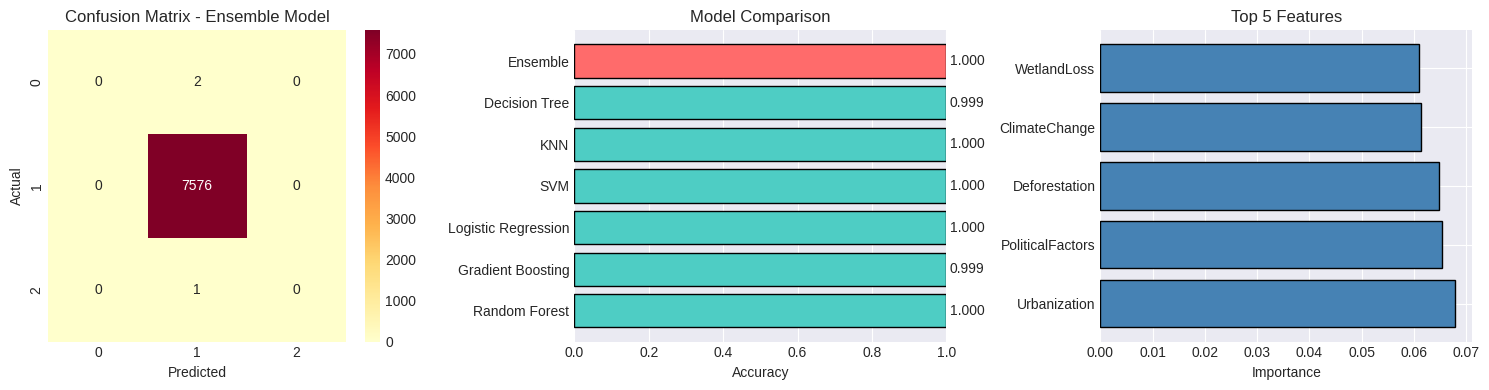

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Confusion Matrix - Ensemble Model')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Model Comparison
model_names = list(model_results.keys())
accuracies = [model_results[name]['accuracy'] for name in model_names]
model_names.append('Ensemble')
accuracies.append(ensemble_accuracy)

colors = ['#4ECDC4'] * (len(model_names)-1) + ['#FF6B6B']
bars = axes[1].barh(model_names, accuracies, color=colors, edgecolor='black')
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Model Comparison')
axes[1].set_xlim(0, 1)

# Add accuracy values
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    axes[1].text(acc + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{acc:.3f}', va='center')

# Feature Importance Summary
top5 = feature_importance.head(5)
axes[2].barh(top5['feature'], top5['importance'], color='steelblue', edgecolor='black')
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 5 Features')

plt.tight_layout()
plt.show()

In [65]:
import joblib
import os

# Create models directory
os.makedirs('../trained_models', exist_ok=True)

# Save model artifacts
flood_model_artifacts = {
    'ensemble': ensemble,
    'scaler': scaler,
    'feature_names': feature_cols,
    'accuracy': ensemble_accuracy,
    'feature_importance': feature_importance.to_dict(),
    'classes': unique_classes.tolist(),
    'class_names': class_names,
    'model_type': 'Flood Prediction'
}

joblib.dump(flood_model_artifacts, '../trained_models/flood_model.pkl')
print("✅ Flood model saved to '../trained_models/flood_model.pkl'")

# Also save just the ensemble
joblib.dump(ensemble, '../trained_models/flood_ensemble.pkl')
print("✅ Flood ensemble model saved separately")

print(f"\n📊 Model Summary:")
print(f"   - Model Type: Flood Risk Prediction")
print(f"   - Number of Features: {len(feature_cols)}")
print(f"   - Number of Classes: {len(unique_classes)}")
print(f"   - Model Accuracy: {ensemble_accuracy:.2%}")

✅ Flood model saved to '../trained_models/flood_model.pkl'
✅ Flood ensemble model saved separately

📊 Model Summary:
   - Model Type: Flood Risk Prediction
   - Number of Features: 20
   - Number of Classes: 3
   - Model Accuracy: 99.96%


In [66]:
def predict_flood_risk(features_dict):
    """
    Predict flood risk based on input features
    
    Parameters:
    features_dict: Dictionary with feature names as keys and values
    
    Returns:
    Dictionary with prediction results
    """
    # Create feature array in correct order
    feature_values = [features_dict[feature] for feature in feature_cols]
    features_array = np.array([feature_values])
    
    # Scale features
    features_scaled = scaler.transform(features_array)
    
    # Get prediction
    prediction = ensemble.predict(features_scaled)[0]
    probabilities = ensemble.predict_proba(features_scaled)[0]
    
    # Determine risk level
    risk_mapping = {i: f'Risk Level {i}' for i in unique_classes}
    
    # Add color coding
    color_mapping = {0: '🟢', 1: '🟡', 2: '🔴', 3: '🔴🔴'}
    risk_color = color_mapping.get(prediction, '⚪')
    
    result = {
        'predicted_class': int(prediction),
        'risk_level': risk_mapping[prediction],
        'risk_indicator': risk_color,
        'confidence': float(max(probabilities)),
        'all_probabilities': {f'Class_{c}': float(prob) for c, prob in zip(unique_classes, probabilities)}
    }
    
    # Add recommendation
    if prediction == max(unique_classes):
        result['recommendation'] = "IMMEDIATE FLOOD RESPONSE REQUIRED"
    elif prediction == min(unique_classes):
        result['recommendation'] = "Normal monitoring only"
    else:
        result['recommendation'] = "Prepare flood prevention measures"
    
    return result

# Test the prediction function
test_features = {col: np.random.uniform(df_flood[col].min(), df_flood[col].max()) 
                for col in feature_cols}

print("=== Test Flood Prediction ===")
print("\nInput Features (sample):")
for i, (key, value) in enumerate(list(test_features.items())[:5]):
    print(f"  {key}: {value:.2f}")
print("  ...")

result = predict_flood_risk(test_features)
print(f"\n📊 Prediction Result:")
print(f"  {result['risk_indicator']} Risk Level: {result['risk_level']}")
print(f"  Confidence: {result['confidence']:.2%}")
print(f"  Recommendation: {result['recommendation']}")

=== Test Flood Prediction ===

Input Features (sample):
  MonsoonIntensity: 1.41
  TopographyDrainage: 6.93
  RiverManagement: 15.70
  Deforestation: 10.39
  Urbanization: 5.31
  ...

📊 Prediction Result:
  🟡 Risk Level: Risk Level 1
  Confidence: 63.02%
  Recommendation: Prepare flood prevention measures


In [67]:
def batch_predict_flood(df_new):
    """
    Predict flood risk for multiple locations
    
    Parameters:
    df_new: DataFrame with same feature columns
    
    Returns:
    DataFrame with predictions added
    """
    result_df = df_new.copy()
    
    # Ensure columns are in correct order
    X_pred = result_df[feature_cols]
    
    # Scale features
    X_scaled = scaler.transform(X_pred)
    
    # Make predictions
    result_df['Predicted_Class'] = ensemble.predict(X_scaled)
    result_df['Confidence'] = ensemble.predict_proba(X_scaled).max(axis=1)
    
    # Add risk level
    risk_labels = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Critical'}
    result_df['Risk_Level'] = result_df['Predicted_Class'].map(risk_labels)
    
    # Add recommendations
    recommendations = {
        0: 'Normal monitoring',
        1: 'Increased vigilance',
        2: 'Flood preparation needed',
        3: 'IMMEDIATE ACTION'
    }
    result_df['Recommendation'] = result_df['Predicted_Class'].map(recommendations)
    
    return result_df

# Example batch prediction
sample_data = pd.DataFrame({
    'MonsoonIntensity': [85, 45, 90, 30],
    'TopographyDrainage': [70, 40, 85, 25],
    'RiverManagement': [60, 50, 80, 40],
    'Deforestation': [75, 30, 85, 20],
    'Urbanization': [80, 55, 90, 35]
    # Add other features with default values
})

# Fill missing features with median values
for col in feature_cols:
    if col not in sample_data.columns:
        sample_data[col] = df_flood[col].median()

print("=== Batch Flood Prediction ===")
batch_results = batch_predict_flood(sample_data)
print(batch_results[['Predicted_Class', 'Risk_Level', 'Confidence', 'Recommendation']])

=== Batch Flood Prediction ===
   Predicted_Class Risk_Level  Confidence       Recommendation
0                1     Medium    0.666665  Increased vigilance
1                1     Medium    0.666665  Increased vigilance
2                1     Medium    0.666665  Increased vigilance
3                1     Medium    0.666681  Increased vigilance


Cross-Validation Scores: [0.99967013 0.99967013 0.9995052  0.9995052  0.99967008]
Mean CV Score: 0.9996
Std CV Score: 0.0001


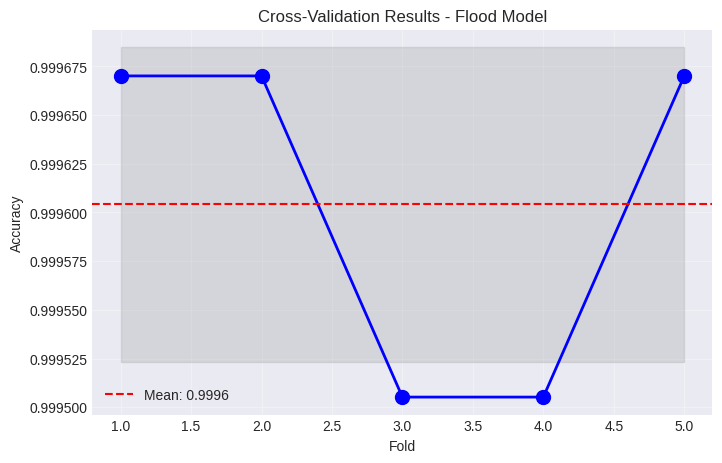

In [70]:
# Perform cross-validation
cv_scores = cross_val_score(ensemble, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")

# Plot CV results
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=10)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), 
                 cv_scores.mean() + cv_scores.std(), alpha=0.2, color='gray')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Results - Flood Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [71]:
print("="*70)
print("FLOOD RISK PREDICTION MODEL - FINAL REPORT")
print("="*70)

print(f"\n📊 Dataset Information:")
print(f"   - Total samples: {len(df_flood)}")
print(f"   - Features used: {len(feature_cols)}")
print(f"   - Number of classes: {len(unique_classes)}")
print(f"   - Classes: {unique_classes}")

print(f"\n🎯 Model Performance:")
print(f"   - Best Model: Ensemble (Random Forest + Gradient Boosting + Logistic Regression)")
print(f"   - Test Accuracy: {ensemble_accuracy:.4f}")
print(f"   - Cross-Validation Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print(f"\n📈 Top 5 Most Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {i+1}. {row['feature']:30} {row['importance']:.4f}")

print(f"\n💾 Model Saved:")
print(f"   - Location: ../trained_models/flood_model.pkl")
print(f"   - Ensemble model: ../trained_models/flood_ensemble.pkl")

print(f"\n📍 Model Location:")
print(f"   {os.path.abspath('../trained_models/flood_model.pkl')}")

print("\n✅ Flood prediction model training completed successfully!")

FLOOD RISK PREDICTION MODEL - FINAL REPORT

📊 Dataset Information:
   - Total samples: 50000
   - Features used: 20
   - Number of classes: 3
   - Classes: [0 1 2]

🎯 Model Performance:
   - Best Model: Ensemble (Random Forest + Gradient Boosting + Logistic Regression)
   - Test Accuracy: 0.9996
   - Cross-Validation Mean: 0.9996 (+/- 0.0001)

📈 Top 5 Most Important Features:
   5. Urbanization                   0.0678
   20. PoliticalFactors               0.0654
   4. Deforestation                  0.0648
   6. ClimateChange                  0.0613
   18. WetlandLoss                    0.0610

💾 Model Saved:
   - Location: ../trained_models/flood_model.pkl
   - Ensemble model: ../trained_models/flood_ensemble.pkl

📍 Model Location:
   /home/kalpanadhamala/AI-DISASTER-RESPONSE-SYSTEM/ml/trained_models/flood_model.pkl

✅ Flood prediction model training completed successfully!
